### 使用langgraph构建代码助手
****
- 针对特定问题参考材料迭代式的生成代码
- 从用户指定的一组文档开始
- 使用长上下文LLM来提取它并执行RAG来回答基于它的问题
- 调用一个工具来生成结构化输出
- 将解决方案返回给用户之前，将执行两个单元测试（检查导入和代码执行）
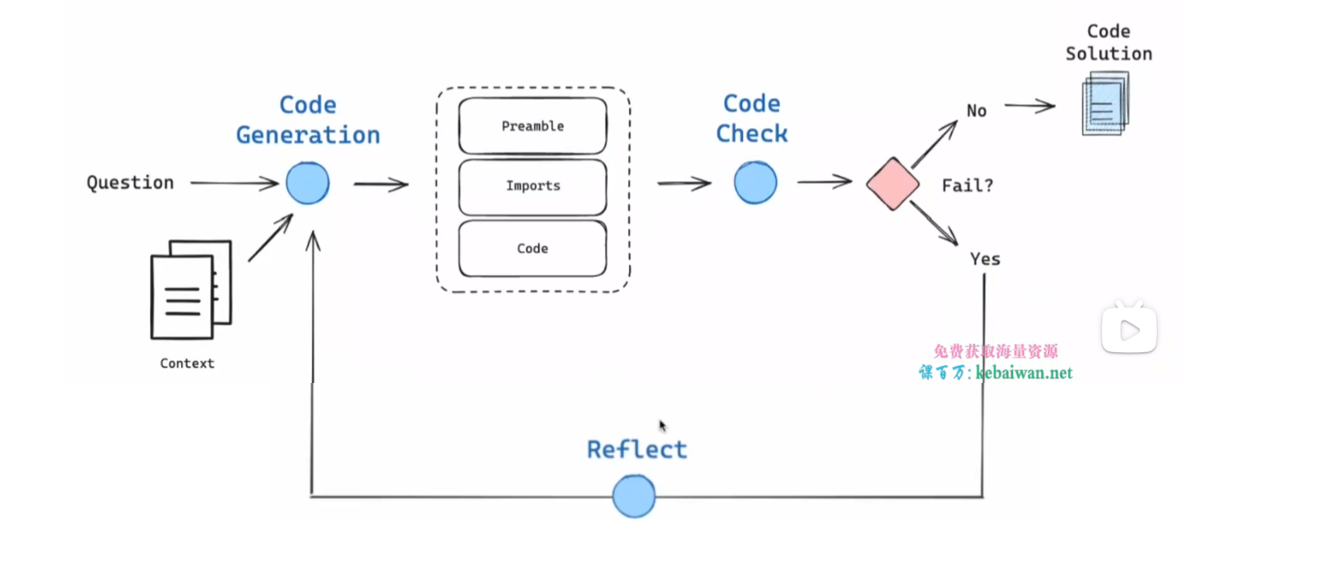

In [ ]:
%pip install -U langchain_community langchain-openai langchain-deepseek langchain langgraph bs4 langchain-anthropic

     ---------------------------------------- 2.4/2.4 MB 3.3 MB/s eta 0:00:00
     ---------------------------------------- 60.5/60.5 kB ? eta 0:00:00
     -------------------------------------- 480.5/480.5 kB 7.6 MB/s eta 0:00:00
     ---------------------------------------- 69.4/69.4 kB 3.9 MB/s eta 0:00:00
     ---------------------------------------- 1.3/1.3 MB 2.9 MB/s eta 0:00:00
     ---------------------------------------- 43.8/43.8 kB 2.1 MB/s eta 0:00:00
     ---------------------------------------- 67.5/67.5 kB 3.6 MB/s eta 0:00:00
     ---------------------------------------- 46.0/46.0 kB ? eta 0:00:00
     ---------------------------------------- 97.5/97.5 kB 5.5 MB/s eta 0:00:00
     ---------------------------------------- 42.2/42.2 kB 2.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 加载LCEL文档
****

In [3]:
from bs4 import BeautifulSoup as Soup
from langchain_community.document_loaders.recursive_url_loader import RecursiveUrlLoader

#LCEL docs
url = "https://python.langchain.com/docs/concepts/lcel/"
loader = RecursiveUrlLoader(
    url = url,max_depth=5,extractor=lambda x: Soup(x,"html.parser").text,
    timeout=30,           # 每个请求最多等30秒
    check_response_status=True,  # 跳过加载失败的页面
)
docs = loader.load()

d_sorted = sorted(docs,key=lambda x:x.metadata["source"])
d_reversed = list(reversed(d_sorted))
concatented_content = "\n\n\n --- \n\n\n".join(
    [doc.page_content for doc in d_reversed]
)

In [6]:
concatented_content

'LangChain overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what\'s next for agents. Get your tickets →Docs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewOverviewDeep AgentsManaged Deep AgentsLangChainLangGraphOpenWikiIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryEvent streamingStreamingStructured outputMiddlewareOverviewPrebuilt middlewareCustom middlewareFrontendOverviewPatternsIntegrationsAdvanced usageGuardrailsRuntimeContext engineeringMCPHuman-in-the-loopMulti-agentRetrievalLong-term memoryAgent developmentLangSmith StudioTestAgent Chat UIProductionDeploymentObservabilityOn 

设置大模型

In [11]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_deepseek import ChatDeepSeek
from pydantic import BaseModel,Field
import os

#OpenAI

code_gen_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """你是一位精通LCEL（LangChain表达式语言）的编程助手。\n
    这里是LCEL文档的完整集合：\n ------ \n   {context}   \n ------\n 请
    根据上述提供的文档回答用户问题。确保你提供的任何代码都可以执行， \n
    包含所有必要的导入和已定义的变量。请按照以下结构组织你的回答：首先描述代码解决方案， \n 
    然后列出导入语句，最后给出功能完整的代码块。以下是用户问题：""",
        ),
        ("placeholder","{messages}"),
    ]
)

#数据模型
class code(BaseModel):
    """LCEL问题代码解决方案的模式"""

    prefix: str = Field(description="问题和解决方案的描述")
    imports:str = Field(description="代码块和导入语句")
    code:str = Field(description="不包括导入语句的代码块")

llm = ChatDeepSeek(
    model="Pro/deepseek-ai/DeepSeek-V3",
    temperature=0,
    api_key=os.environ.get("DEEPSEEK_API_KEY"),
    base_url=os.environ.get("DEEPSEEK_API_BASE"),
)
code_gen_chain_oai = code_gen_prompt | llm.with_structured_output(code)
question = "如何在LCEL中构建RAG链?"
solution = code_gen_chain_oai.invoke(
    {"context":concatented_content,"messages":[("user",question)]}
)
solution

code(prefix='在LCEL中构建RAG（Retrieval-Augmented Generation）链通常涉及两个主要步骤：检索（Retrieval）和生成（Generation）。检索步骤从外部知识库中获取相关信息，而生成步骤则基于检索到的信息生成回答。以下是一个简单的RAG链实现示例。', imports='from langchain.embeddings import OpenAIEmbeddings\nfrom langchain.vectorstores import FAISS\nfrom langchain.chat_models import ChatOpenAI\nfrom langchain.schema.runnable import RunnablePassthrough\nfrom langchain.prompts import ChatPromptTemplate', code='# 假设我们有一个文档列表\ndocuments = ["文档1内容", "文档2内容", "文档3内容"]\n\n# 初始化嵌入模型\nembeddings = OpenAIEmbeddings()\n\n# 创建向量存储\nvectorstore = FAISS.from_texts(documents, embeddings)\n\n# 定义检索器\nretriever = vectorstore.as_retriever()\n\n# 定义生成模型\nllm = ChatOpenAI()\n\n# 定义提示模板\nprompt = ChatPromptTemplate.from_template(\n    "基于以下上下文回答问题：\\n{context}\\n\\n问题：{question}"\n)\n\n# 构建RAG链\nrag_chain = (\n    {"context": retriever, "question": RunnablePassthrough()}\n    | prompt\n    | llm\n)\n\n# 调用RAG链\nresult = rag_chain.invoke("你的问题是什么？")\nprint(result)')

In [13]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

###OpenAI

# 强制使用工具的提示
code_gen_prompt_glm = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """<instructions> 你是一位精通LCEL（LangChain表达式语言）的编程助手。\n
    这里是LCEL文档的完整集合：\n ------ \n   {context}   \n ------\n 请根据上述提供的文档回答用户问题。 \n
    确保你提供的任何代码都可以执行，包含所有必要的导入和已定义的变量。 \n
    按一下结构组织你的回答：1)描述代码解决方案的前言，2)导入语句，3)功能完整的代码块。 \n
    调用code工具来正确构建输出。</instructions> \n 一下是用户问题""",
        ),
        ("placeholder","{messages}"),
    ]
)

#大语言模型
#注意选择使用zai-org/GLM-5.3模型，因为其上下文窗口更大1024k
expt_llm = "zai-org/GLM-5.3"
llm = ChatOpenAI(
    model = expt_llm,
    api_key=os.environ.get("DEEPSEEK_API_KEY"),
    base_url=os.environ.get("DEEPSEEK_API_BASE"),
)

structured_llm_glm = llm.with_structured_output(code,include_raw=True)

# 可选：检查工具是否出现错误
def check_glm_output(tool_output):
    """检查解析错误或未能调用工具"""

    #解析错误
    if tool_output["parsing_error"]:
        #报告输出和解析错误
        print("解析错误")
        raw_output = str(tool_output["raw"].content)
        error = tool_output["parsing_error"]
        raise ValueError(
            f"解析输出时出错！请确保调用工具。输出：{raw_output}。 \n 解析错误：{error}"
        )

    #未调用工具
    elif not tool_output["parsing_error"]:
        print("未能调用工具！")
        raise ValueError(
            "你没有使用提供的工具。请确保调用工具来构建输出"
        )
    return tool_output

#带输出检查的链
code_chain_glm_raw = (
    code_gen_prompt_glm | structured_llm_glm | check_glm_output
)

def insert_errors(inputs):
    """在消息中插入工具解析错误"""

    #获取错误
    error = inputs["error"]
    messages = inputs["messages"]
    messages += [
        (
            "assistant"
            f"重试。你需要修复解析错误：{error} \n\n 你必须调用提供的工具。",
        )
    ]
    return {
        "messages":messages,
        "context":inputs["context"]
    }

#这将作为后备链运行
fallback_chain = insert_errors | code_chain_glm_raw
N = 3 #最大重试次数
code_gen_chain_re_try = code_chain_glm_raw.with_fallbacks(
    fallbacks=[fallback_chain] * N,exception_key = "error"
)

def parse_output(solution):
    """当我们在结构化输出中添加'include_raw'=True时，
    它将返回一个包含'raw'、'parsed'、'parsing_error'的字典。"""

    return solution["parsed"]

#可选：带重试功能，用于纠正未能调试工具的情况
code_gen_chain = code_gen_chain_re_try | parse_output

#不重试
code_gen_chain = code_gen_prompt_glm | structured_llm_glm |parse_output

In [14]:
#Test
question = "在LCEL中如何构建一个RAG链"
solution = code_gen_chain.invoke(
    {"context":concatented_content,"messages":[("user",question)]}
)
solution

code(prefix='在LCEL中构建RAG链的核心思想是：用管道操作符 `|` 把“检索”与“生成”声明式地组装成一条链。检索器、提示模板、聊天模型、输出解析器本身都是`Runnable`，因此可以直接拼接。典型的RAG链结构如下：\n\n1. `RunnableParallel` 把输入字典拆成并行的两条分支：\n   - **context 分支**：`itemgetter("question") | retriever | format_docs` —— 取出用户问题 → 向量检索最相关的文档 → 拼接成上下文文本；\n   - **question 分支**：`itemgetter("question")` —— 用户问题原样保留；\n2. 两路输出合并为 `{context, question}`，填入 `ChatPromptTemplate`；\n3. 后接聊天模型和 `StrOutputParser`，得到纯文本答案。\n\n这样组装出来的链自动获得 `invoke / stream / batch` 及对应异步方法，还可用LangSmith全链路追踪（设置 `LANGSMITH_TRACING=true` 即可）。\n\n运行前需安装依赖并配置API Key：\n\n```bash\npip install -qU langchain "langchain[openai]"\nexport OPENAI_API_KEY="sk-..."\n```', imports='from operator import itemgetter\n\nfrom langchain.chat_models import init_chat_model\nfrom langchain_core.documents import Document\nfrom langchain_core.output_parsers import StrOutputParser\nfrom langchain_core.prompts import ChatPromptTemplate\nfrom langchain_core.runnables import RunnableParallel\nfrom langchain_core.vectorstores import In

定义state

In [15]:
from typing import List
from typing_extensions import TypedDict

class GraphState(TypedDict):
    """
    表示我们图的状态

    属性：
        error：用于控制流的二进制标志，表示是否触发了测试错误
        messages：包含用户问题、错误消息、推理过程
        generation：代码解决方案
        iterations：尝试次数
    """

    error:str
    messages:List
    generation:str
    iterations:int

创建节点

In [16]:
###参数

#最大尝试次数
max_iterations = 3
#反思
#flag = 'reflect'
flag = "do not reflect" # 不进行反思

###节点

def generate(state:GraphState):
    """
    生成代码解决方案

    参数：
        state(dict):当前图状态

    返回：
        state(dict):向状态添加新键,generation
    """

    print("---正在生成解决方案---")

    #状态
    messages = state["messages"]
    iterations = state["iterations"]
    error = state["error"]

    #我们因错误被重新路由到生成
    if error == "yes":
        messages += [
            (
                "user",
                "现在，请重试。调用code工具来构建包含前言、导入和代码块的输出：",
            )
        ]

    #解决方案
    code_solution = code_gen_chain.invoke(
        {"context":concatented_content,"messages":messages}
    )
    messages += [
        (
            "assistant",
            f"{code_solution.prefix} \n 导入：{code_solution.imports} \n 代码：{code_solution.code}"
        )
    ]

    #增加计数
    iterations = iterations + 1
    return {"generation":code_solution,"messages":messages,"iterations":iterations}

def code_check(state:GraphState):
    """
    检查代码

    参数：
        state(dict):当前图状态

    返回：
        state(dict):向状态添加新键，error
    """

    print("---正在检查代码---")

    #状态
    messages = state["messages"]
    code_solution = state["generation"]
    iterations = state["iterations"]

    #获取解决方案组件
    imports = code_solution.imports
    code = code_solution.code

    #检查导入
    try:
        exec(imports)
    except Exception as e:
        print("---代码导入检查：失败---")
        error_message = [("user",f"你的解决方案未通过导入测试：{e}")]
        messages += error_message
        return {
            "generation":code_solution,
            "messages":messages,
            "iterations":iterations,
            "error":"yes",
        }

    #无错误
    print("---无代码测试失败---")
    return {
        "generation":code_solution,
        "messages":messages,
        "iterations":iterations,
        "error":"no",
    }

def reflect(state:GraphState):
    """
    对错误进行反思

    参数：
        state(dict):当前图状态

    返回：
        state(dict):向状态添加新键，generation
    """

    print("---正在生成代码解决方案---")

    #状态
    messages = state["messages"]
    code_solution = state["generation"]
    iterations = state["iterations"]

    #提示反思

    #添加反思
    reflections = code_gen_chain.invoke(
        {"context":concatented_content,"messages":messages}
    )
    messages += [("assistant",f"以下是对错误的反思：{reflections}")]
    return {"generation":code_solution,"messages":messages,"iterations":iterations}

###边缘

def decide_to_finish(state:GraphState):
    """
    确定是否结束。

    参数：
        state(dict):当前图状态

    返回：
        str:要调用的下一个节点
    """
    error = state["error"]
    iterations = state["iterations"]

    if error == "no" or iterations == max_iterations:
        print("---决定：完成---")
        return "end"
    else:
        print("---决定：重新尝试解决方案---")
        if flag == "reflet":
            return "reflect"
        else:
            return "generate"

创建工作流

In [17]:
from langgraph.graph import END,StateGraph,START

workflow = StateGraph(GraphState)

workflow.add_node("generate",generate)
workflow.add_node("check_code",code_check)
workflow.add_node("reflect",reflect)

workflow.add_edge(START,"generate")
workflow.add_edge("generate","check_code")
workflow.add_conditional_edges(
    "check_code",
    decide_to_finish,
    {
        "end":END,
        "reflect":"reflect",
        "generate":"generate",
    },
)
workflow.add_edge("reflect","generate")
app = workflow.compile()

测试

In [19]:
question = "如何在runnable中传递原始的输入？"
solution = app.invoke({"messages":[("user",question)],"iterations":0,"error":""})

---正在生成解决方案---
---正在检查代码---
---无代码测试失败---
---决定：完成---


In [20]:
solution["generation"]

code(prefix='在 LCEL 中，管道 `A | B | C` 的数据单向流动，`C` 默认只能看到 `B` 的输出，看不到链的最初输入。当某个下游步骤需要访问原始输入时（最典型的是 RAG：prompt 必须同时拿到「用户原始问题」和「检索到的 context」），需要显式地在链条里为原始输入开辟传递通道。标准做法有三种：\n\n1. **`RunnablePassthrough()` 占位**：在 `RunnableParallel`/字典分支中，`RunnablePassthrough` 将收到的输入不做任何修改原样输出，因此该分支的值就是链的原始输入；\n2. **`RunnablePassthrough.assign()`**：输入是 dict 时，保留原始输入的所有键，再追加新计算的字段，原始信息全程不丢失；\n3. **`itemgetter("key")`**：与 `RunnableParallel` 组合，从原始输入 dict 中按 key 提取特定字段。\n\n下面的代码用 `RunnableLambda` 模拟 retriever 和模型（无外部 API 依赖），三种方法均可直接运行并打印结果验证。', imports='from operator import itemgetter\n\nfrom langchain_core.runnables import (\n    RunnableLambda,\n    RunnableParallel,\n    RunnablePassthrough,\n)', code='# ------------------------------------------------------------------\n# 前言：解决思路说明\n# ------------------------------------------------------------------\n# 在 LCEL 中，链条数据流是从左到右单向流动：`A | B | C` 中，\n# runable C 只能看到 B 的输出，无法访问链的最初输入。\n# 若下游步骤还需要链的原始输入（例如 RAG 场景中，prompt 同时需要\n# "用户原始问题" 和 "检索结果"），有三种标准做法：\n#\n#   